# 4.26

$$ \epsilon_n = E_n - E_c $$

$$ \epsilon_n = \frac{h^2 n^2}{8m_e^* d^2}$$

where n is the quantum number

Additionally,
$$ \epsilon_{n'} = E_{n'} - E_c $$

$$ \epsilon_{n'} = \frac{h^2 n'^2}{8m_h^* d^2}$$

In [146]:
import numpy as np
from scipy.constants import h, e

d = 10e-9
m_star_e = 0.04*9.1*10**-31
m_star_h = 0.44*9.1*10**-31

n= np.array([1, 2])
n_prime = np.array([1])

epsilon_n = h**2 * n**2 / (8*m_star_e * d**2) / e
epsilon_n_prime = h**2 * n_prime**2 / (8*m_star_h * d**2) / e

print("First and Second Energy Levels Above Conduction Band")
for _n, _epsilon_n in zip(n, epsilon_n):
    print(f"ε_{_n} = {_epsilon_n} eV")

print()
print("First Energy Level Below Valence Band")
for _n_prime, _epsilon_n_prime in zip(n_prime, epsilon_n_prime):
    print(f"ε_{_n_prime}' = {_epsilon_n_prime} eV")

First and Second Energy Levels Above Conduction Band
ε_1 = 0.09410447897289292 eV
ε_2 = 0.3764179158915717 eV

First Energy Level Below Valence Band
ε_1' = 0.008554952633899358 eV


For Quantum Wells, we must obey the selection rules:  
$$ \Delta n = n' - n = 0 $$

which implies radiative transition is from $\epsilon_1$ to $\epsilon_1'$ is  
$$ \lambda_{QW} = \frac{hc}{E_g + \epsilon_1 + \epsilon_1 '} $$

In [147]:
epsilon_1 = epsilon_n[np.where(n==1)[0][0]]
epsilon_1_prime = epsilon_n_prime[np.where(n_prime==1)[0][0]]


In [148]:
from scipy.constants import c

E_g = 0.7 # eV
lam_QW = h*c / (e*(E_g + epsilon_1 + epsilon_1_prime))

print(f"Lasing Emission Wavelength for this SQW laser:")
print(f"λ_QW = {lam_QW:e}")

Lasing Emission Wavelength for this SQW laser:
λ_QW = 1.544668e-06


In [149]:
print(f"Wavelgenth if this transition were to occur in bulk InGaAs: ")
lam_bulk = h*c / (e*(E_g))
print(f"λ_bulk = {lam_bulk:e}")

Wavelgenth if this transition were to occur in bulk InGaAs: 
λ_bulk = 1.771203e-06


# 4.27

$$ \Gamma g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Because no information is given about the refractive indices of the cladding regions, we may assume

$$ \Gamma = 1 $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Since we know how the refractive index changes with temperature, we will rewrite the gain equation in terms of the refractive index, and then in terms of temperature. We also assume that $R_1 = R_2 = \frac{(n - 1)^2}{(n+1)^2}$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1^2}) = \alpha_s + \frac{1}{2L}ln(\frac{(n+1)^4}{(n - 1)^4}) $$

We are only told the first derivative of $n$ with respect to temperature, so we will assume it can be approximated as linear.  

$$ n = n_{ambient} +\frac{dn}{dT}(T - 300) $$
$$ n = 3.6 + 0.00025(T - 300) $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{(4.6 + 0.0002(T - 300))^4}{(2.6 + 0.0002(T - 300))^4}) $$

The dimensions of linear expansion are $\frac{[\Delta L \space microns]}{[L \space meters][\Delta T]}$, and since we know the length of the cavity at ambient temperature, we can express  
$$L = L_{ambient}( 1 + \alpha_L \Delta T) $$
$$ L = (1 + 5.8 \times 10^{-6} (T - 300)) \times 200\space \mu m  $$

$$ g_{th} = \alpha_s + \frac{1}{2(1 + 5.6 \times 10^{-6} (T - 300)) \times 250\space \mu m }ln(\frac{(4.6 + 0.0002(T - 300))^4}{(2.6 + 0.0002(T - 300))^4}) $$

Clearly, this will have a non-trivial solution, so instead we plot this function, notice it is essentially linear over a large temperature range, and we determine numerically the slope of $g_{th}$.

Next, we must find how emission wavelength for a given mode changes per unit temperature change.

for a given mode the emission frequency is
$$ \nu_m = \frac{mc}{2nL} $$
Where m is an integer indicating the mode number
$$ \lambda_m = \frac{c}{\nu_m} $$

Without reference to the specific mode number we continue
$$ \lambda = \frac{c}{\nu} $$

We can rewrite $\nu$ in terms of the bandgap  

$$ \nu = \frac{E_g}{h} $$
$$ \lambda = \frac{hc}{E_g} = \frac{hc}{E_{go} - AT^2/(B+T)}$$

Taking the derivative  
$$ \frac{d}{d\lambda} = -\frac{hc}{(E_{go} - AT^2/(B+T))^2 }\times \frac{2AT(B+T) - AT^2}{(B+T)^2}$$
$$ \frac{d}{d\lambda} = -\frac{hc}{(E_{go} - AT^2/(B+T))^2 }\times \frac{2ATB+AT^2}{(B+T)^2}$$

Again, this 

In [150]:
lam = 1550e-9
L = 250e-6
alpha_s = 0.0
n_room_temp = 3.60 # refractive index, at room temperature I think
dn_dT = 2e-4 # K^-1
linear_thermal_expansion = 5.6e-6 # K^-1
E_go = 0.850 # eV
A = 4.906e-4 # eV
B = 301 # K

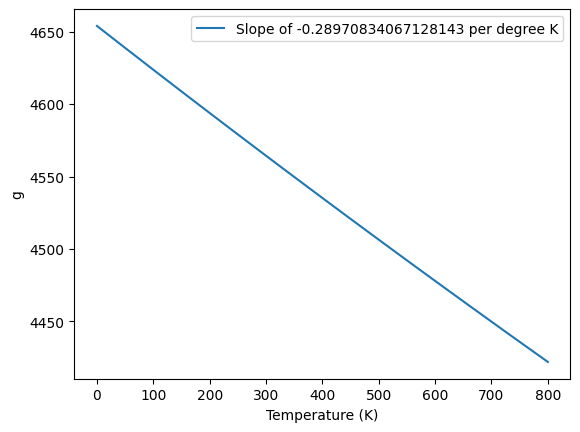

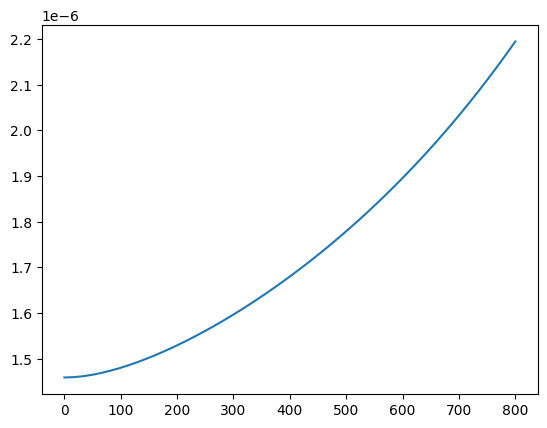

In [153]:
import matplotlib.pyplot as plt



T = np.linspace(0, 800)
alpha_T = 5.6*10**-6
n = n_room_temp - dn_dT*(300 - T)
L = (1 + alpha_T * (T-300)) * 250e-6
# plt.plot(T, n)

R = (n-1)**2 / (n+1)**2 # Assuming that this is at 
# x = 1/R**2
# plt.plot(x, np.log(1/R**2))
# plt.plot(x, 0.104*x + 1.26)

# plt.show()
g = 1/(2*L) * np.log(1/R**2)

slope, intercept = np.polyfit(T, g, deg=1)

plt.plot(T, g, label=f"Slope of {slope} per degree K")
plt.xlabel("Temperature (K)")
plt.ylabel("g")
plt.legend()
plt.show()

E_g = E_go - A*T**2 / (B+T)
f = (E_g*e) / h
lam = c / f

plt.plot(T, lam)
# plt.plot(T, )

Clearly, the optical gain curve shifts by -0.29 per degree kelvin.

Now, we move onto wavelength

# 4.31

# 4.42

# Me Attempting to solve problem 2 the hard way

$$ \Gamma g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Because no information is given about the refractive indices of the cladding regions, we may assume

$$ \Gamma = 1 $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Since we know how the refractive index changes with temperature, we will rewrite the gain equation in terms of the refractive index, and then in terms of temperature. We also assume that $R_1 = R_2 = \frac{(n - 1)^2}{(n+1)^2}$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1^2}) = \alpha_s + \frac{1}{2L}ln(\frac{(n+1)^4}{(n - 1)^4}) $$

We are only told the first derivative of $n$ with respect to temperature, so we will assume it can be approximated as linear.  

$$ n = n_{ambient} +\frac{dn}{dT}(T - 300) $$
$$ n = 3.6 + 0.00025(T - 300) $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) $$

The dimensions of linear expansion are $\frac{[\Delta L \space microns]}{[L \space meters][\Delta T]}$, and since we know the length of the cavity at ambient temperature, we can express  
$$L = L_{ambient}( 1 + \alpha_L \Delta T) $$
$$ L = (1 + 5.8 \times 10^{-6} (T - 300)) \times 200\space \mu m  $$

$$ g_{th} = \alpha_s + \frac{1}{2(1 + 5.8 \times 10^{-6} (T - 300)) \times 200\space \mu m }ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) $$



Now, we simply differentiate with respect to T  
$$ \frac{d}{dT}g_{th} = 0 + \frac{d}{dT} [\frac{1}{2(1 + 5.8 \times 10^{-6} (T - 300)) \times 200\space \mu m }ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4})] $$

$$ \frac{dg_{th}}{dT} = \frac{d}{dT} [\frac{ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4})}{(400\space \mu m + 2320 \times 10^{-12} (T - 300))}]$$

Using the quotient rule, we obtain  

$$ \frac{dg_{th}}{dT} = \frac{(400\space \mu m + 2320 \times 10^{-12} (T - 300))\times \frac{d}{dT}[ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4})] - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times \frac{d}{dT}[(400\space \mu m + 2320 \times 10^{-12} (T - 300))]}{(400\space \mu m + 2320 \times 10^{-12} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = 2L \frac{(1 + 5.8 \times 10^{-6} (T - 300))\times \frac{d}{dT}[ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4})] - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times \frac{d}{dT}[(1 + 5.8 \times 10^{-6} (T - 300))]}{(2L)^2(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{(1 + 5.8 \times 10^{-6} (T - 300))\times \frac{d}{dT}[ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4})] - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times \frac{d}{dT}[(1 + 5.8 \times 10^{-6} (T - 300))]}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{(1 + 5.8 \times 10^{-6} (T - 300)) \times \frac{(2.6 + 0.00025(T - 300))^4}{(4.6 + 0.00025(T - 300))^4} \times \frac{d}{dT} \frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4} - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times 5.8 \times 10^{-6}}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{(1 + 5.8 \times 10^{-6} (T - 300)) \times \frac{(2.6 + 0.00025(T - 300))^4}{(4.6 + 0.00025(T - 300))^4} \times\frac{ (2.6 + 0.00025(T - 300))^4 \times \frac{d}{dT}[(4.6 + 0.00025(T - 300))^4] - (4.6 + 0.00025(T - 300))^4 \times \frac{d}{dT}[(2.6 + 0.00025(T - 300))^4]}{(2.6 + 0.00025(T - 300))^8} - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times 5.8 \times 10^{-6}}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{(1 + 5.8 \times 10^{-6} (T - 300)) \times \frac{ (2.6 + 0.00025(T - 300))^4 \times \frac{d}{dT}[(4.6 + 0.00025(T - 300))^4] - (4.6 + 0.00025(T - 300))^4 \times \frac{d}{dT}[(2.6 + 0.00025(T - 300))^4]}{(4.6 + 0.00025(T - 300))^4(2.6 + 0.00025(T - 300))^4} - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times 5.8 \times 10^{-6}}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{(1 + 5.8 \times 10^{-6} (T - 300)) \times \frac{ (2.6 + 0.00025(T - 300))^4 \times 4(0.00025)(4.6 + 0.00025(T - 300))^3 - (4.6 + 0.00025(T - 300))^4 \times [4(0.00025)(2.6 + 0.00025(T - 300))^3]}{(4.6 + 0.00025(T - 300))^4(2.6 + 0.00025(T - 300))^4} - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times 5.8 \times 10^{-6}}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$

$$ \frac{dg_{th}}{dT} = \frac{4(0.00025)(1 + 5.8 \times 10^{-6} (T - 300)) \times \frac{ (2.6 + 0.00025(T - 300))^4 - (4.6 + 0.00025(T - 300))^4}{(4.6 + 0.00025(T - 300))(2.6 + 0.00025(T - 300))} - ln(\frac{(4.6 + 0.00025(T - 300))^4}{(2.6 + 0.00025(T - 300))^4}) \times 5.8 \times 10^{-6}}{2L(1 + 5.8 \times 10^{-6} (T - 300))^2} $$